# Tutorial 03 — Heterogeneous Urban Graph

This notebook walks through the construction and visualisation of an **UrbanGraph**: a rich heterogeneous graph that encodes four spatial node types and their topological relationships:

| Node type | Geometry | Typical attributes |
|---|---|---|
| **Plot** | Polygon | Land-use, population, POIs |
| **Building** | Polygon | Area, perimeter, height, compactness |
| **Street** | LineString | Length, SVI indices |
| **Intersection** | Point | Degree, centrality |

The graph is produced by a single call to `get_urban_graph()`, which orchestrates data collection from OSM (streets + buildings), population datasets (Meta / GHS), POIs, and optionally street-view imagery — all for any polygon boundary you supply.

In [1]:
from urbanity import Map
from urbanity.visualisation import (
    plot_graph,
    plot_urban_graph_overview,
    plot_urban_graph_edges,
    plot_buildings,
    plot_node_attribute,
    plot_street_network,
)
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

## 1  Define Study Area

In [2]:
m = Map(country='Singapore')
m.add_polygon_boundary('data/tanjong_pagar_singapore.geojson',
                        layer_name='Tanjong Pagar')
print("Area (km²):",
      round(m.polygon_bounds.to_crs(m.polygon_bounds.estimate_utm_crs()).area.values[0] / 1e6, 2))

Area (km²): 28.13


## 2  Construct the Urban Graph

`get_urban_graph()` returns:
- an `objects` **dict** keyed by layer name (``'plot'``, ``'building'``, ``'street'``, ``'intersection'``, ``'boundary'``)
- a `connections` **dict** of adjacency arrays (NumPy ``int64`` arrays of shape ``(2, E)``)

No `network_filepath` or manual OSM path is required — Urbanity finds the best extract automatically.

In [3]:
urban_graph = m.get_urban_graph(
    bandwidth=100,              # buffer distance (m) beyond the boundary
    minimum_area=30,            # filter plots smaller than 30 m²
    network_type='driving',
    population_layer='meta',    # use Meta 30-m resolution population counts
)

Singapore
Best extract: Singapore (bbbike) — 37.3 MB
Using cached extract: ./data/bbbike_Singapore.osm.pbf (37.3 MB)
Data extracted successfully. Proceeding to construct street network.
Network constructed. Time taken: 9.
Buildings constructed. Time taken: 29.
Urban plots constructed. Time taken: 32.
Adding morphology to plots...
Adding plot morphology to plots...
Adding poi categories to plots...
Adding Meta population counts to plots...
Using non-tiled population data.
Population attributes computed. Time taken: 44.


## 3  Explore the Output

In [4]:
# Node counts by type
for layer, gdf in urban_graph.geo_store.items():
    if hasattr(gdf, '__len__'):
        print(f"{layer:>14s}: {len(gdf):>6,} features")

      boundary:      1 features
      building: 10,196 features
          plot:  2,326 features
        street: 10,167 features
  intersection:  8,051 features


In [5]:
# Initialize graph edges with building neighbours (3 nearest neighbours) within 100 m distance
urban_graph.initialize_edges(building_neighbours = 'knn', knn=3, distance=100)

# Edge (connection) counts
for edge_type, arr in urban_graph.edge_store.items():
    if hasattr(arr, 'shape'):
        print(f"{edge_type:>35s}: {arr.shape[1]:>7,} links")

[get_plot_to_plot_edges] Dropping 23 outer-envelope polygon(s) (area >= 196775 m² and street count > 53.2).
                   boundary_to_plot:   2,326 links
                   plot_to_boundary:   2,326 links
                       plot_to_plot:  10,680 links
               building_to_building:  30,588 links
                 building_to_street:   9,912 links
                 street_to_building:   9,912 links
             intersection_to_street:  20,334 links
             street_to_intersection:  20,334 links
                   building_to_plot:  10,489 links
                   plot_to_building:  10,489 links
                     street_to_plot:  17,460 links
                     plot_to_street:  17,460 links


## 4  Four-Panel Overview

`plot_urban_graph_overview()` lays out all four node layers side-by-side on a dark background.

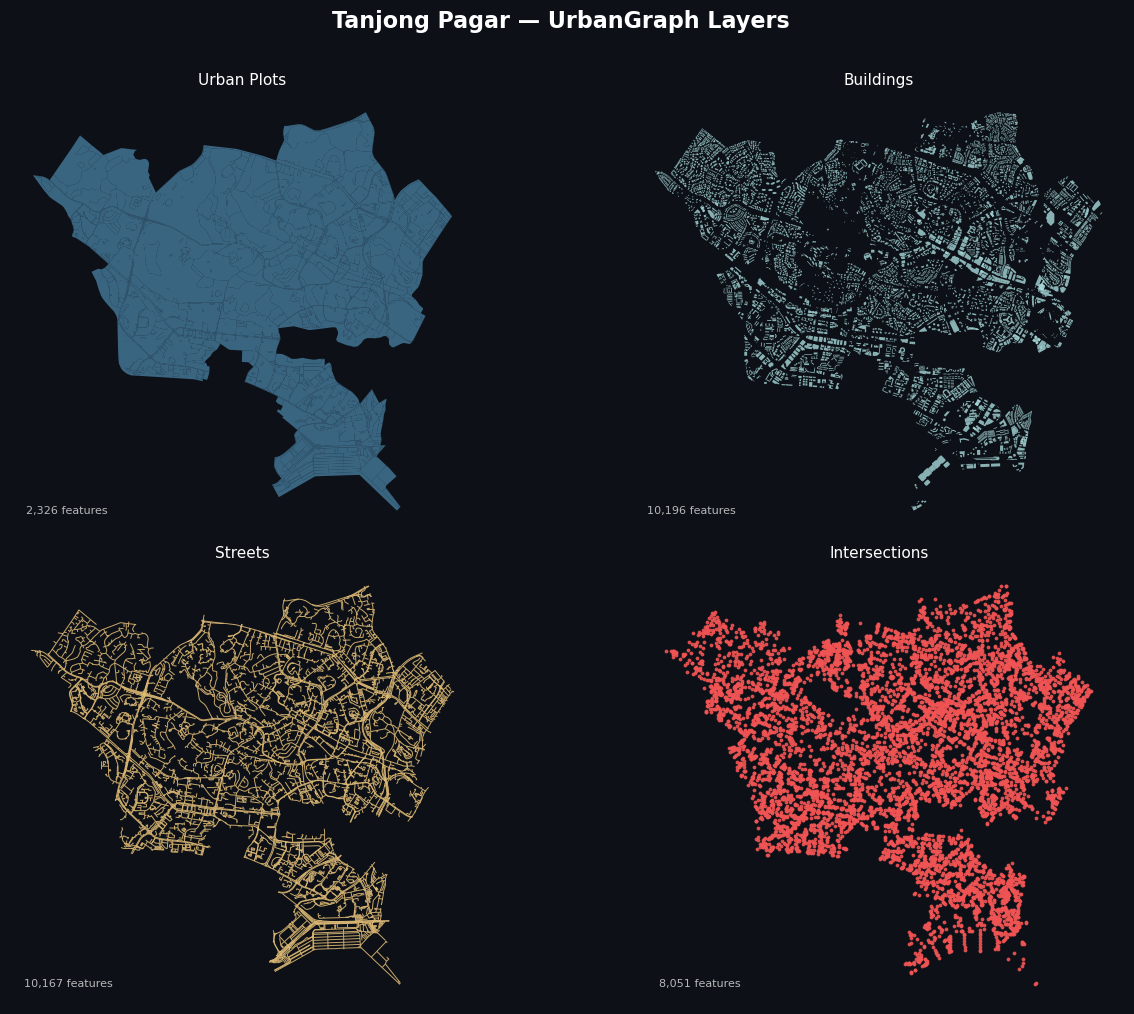

In [6]:
fig = plot_urban_graph_overview(
    urban_graph.geo_store,
    title='Tanjong Pagar — UrbanGraph Layers',
    dark_mode=True,
)
plt.show()

In [7]:
urban_graph.edge_store.keys()

dict_keys(['boundary_to_plot', 'plot_to_boundary', 'plot_to_plot', 'building_to_building', 'building_to_street', 'street_to_building', 'intersection_to_street', 'street_to_intersection', 'building_to_plot', 'plot_to_building', 'street_to_plot', 'plot_to_street'])

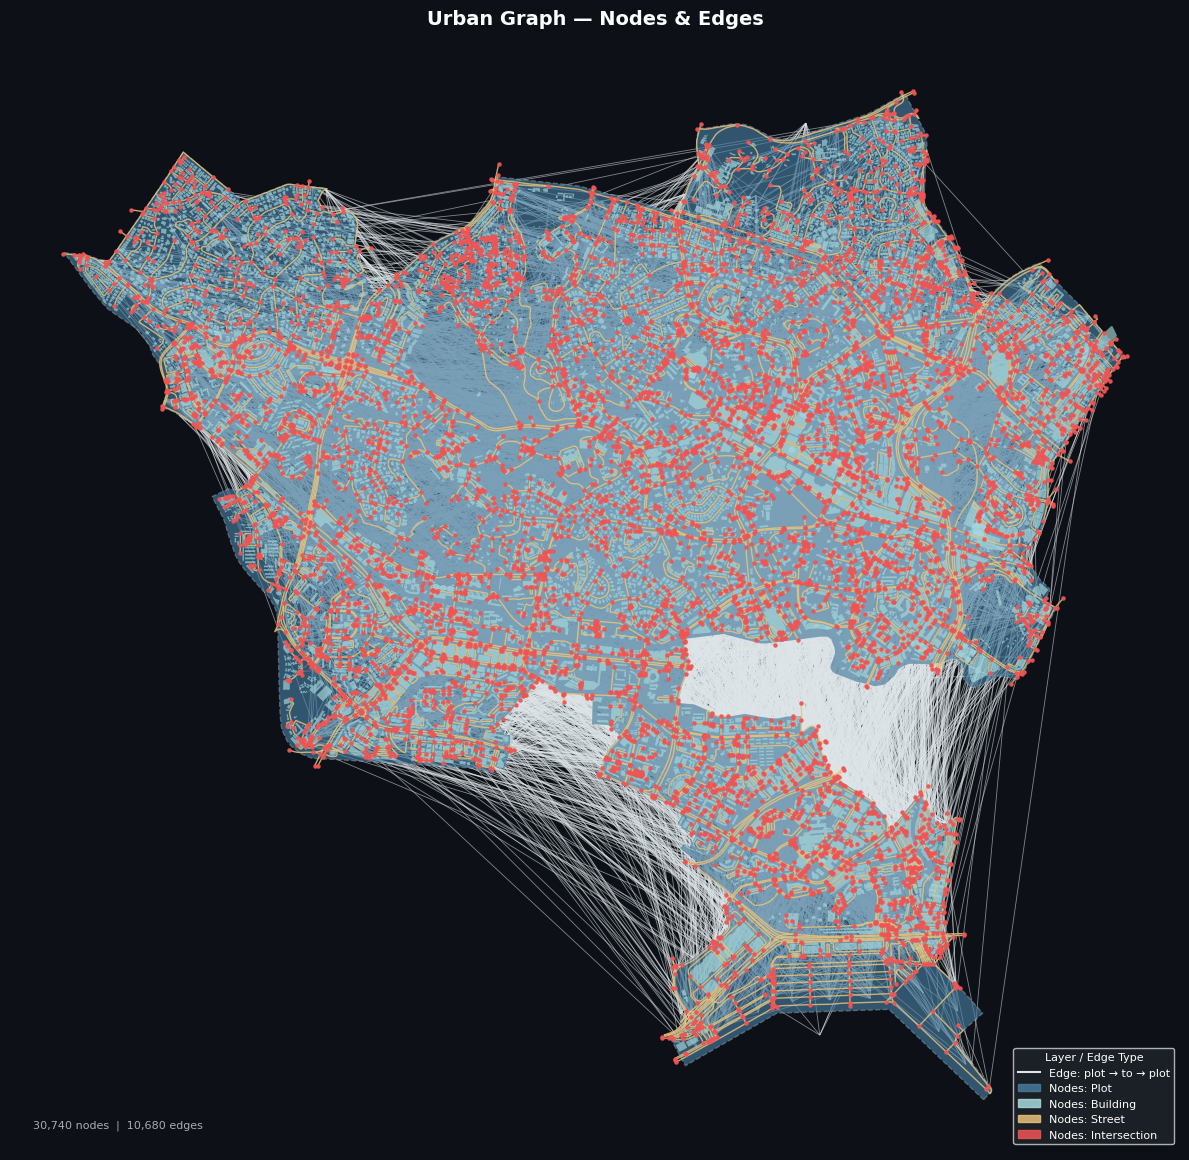

In [8]:
fig = plot_urban_graph_edges(
    urban_graph.geo_store,
    urban_graph.edge_store,
    edge_types=["plot_to_plot"]
)
plt.show()

## 5  Building Footprint Visualisation

In [ ]:
fig = plot_buildings(
    urban_graph.geo_store['building'],
    boundary=urban_graph.geo_store['boundary'],
    title='Building Footprints — Tanjong Pagar',
    dark_mode=True,
)
plt.show()

In [ ]:
# Colour by footprint area
fig = plot_buildings(
    urban_graph.geo_store['building'],
    colname='bid_area',
    cmap='viridis',
    boundary=urban_graph.geo_store['boundary'],
    title='Building Footprint Area (m²)',
    dark_mode=True,
)
plt.show()

## 6  Urban Plot Attribute Map

Use `plot_node_attribute()` for any layer × attribute combination.

In [ ]:
# Choose a numeric column present in the plot GeoDataFrame
numeric_cols = urban_graph.geo_store['plot'].select_dtypes(include='number').columns.tolist()
print("Numeric plot columns:", numeric_cols[:10])

In [ ]:
if numeric_cols:
    fig = plot_node_attribute(
        urban_graph.geo_store['plot'],
        colname=numeric_cols[0],
        geometry_type='polygon',
        cmap='RdYlGn',
        boundary=urban_graph.geo_store['boundary'],
        title=numeric_cols[0].replace('_', ' ').title(),
        dark_mode=True,
    )
    plt.show()

## 7  Interactive 3-D View with PyDeck

`plot_graph()` renders a 3-D interactive Deck.gl visualisation.  
Set `node_type` to choose which layer is highlighted.

In [ ]:
# Building-centric view with height extrusion
plot_graph(urban_graph.geo_store, urban_graph.edge_store, node_type='building', colname='bid_height')

## 8  Highlight a Single Node and Its Neighbours

Pass a `node_id` to `plot_graph()` to highlight one node (in red) along with all connected neighbours across layer types.

In [ ]:
# Highlight plot #0 and all its connected buildings, streets, and intersections
plot_graph(urban_graph.geo_store, urban_graph.edge_store, node_type='plot', node_id=0)

## 9  Convert to PyTorch Geometric Graph for Machine Learning

In [ ]:
urban_graph.to_pyg_graph()

## 10  Save and load urban graph

** For best practice, save graphs before initializing edges as edges might differ across use cases **

In [ ]:
urban_graph.geo_store['plot'].columns

In [ ]:
# Saving graph for future work
urban_graph.save_graph('./data/graph.zip')

# Loading graph in future session
from urbanity.data_class import UrbanGraph
new_graph = UrbanGraph()
new_graph.load_graph('./data/graph.zip')


## Summary

| Task | Function |
|---|---|
| Build heterogeneous graph | `m.get_urban_graph()` |
| Four-panel overview | `plot_urban_graph_overview(objects)` |
| Building footprint map | `plot_buildings(objects['building'])` |
| Any node × attribute map | `plot_node_attribute(gdf, colname=...)` |
| Interactive 3-D view | `plot_graph(objects, connections, node_type=...)` |
| Highlight a single node | `plot_graph(..., node_id=N)` |